# Chapter 4 — Numerical Integration
### TA Session · Burden & Burden, *Numerical Analysis*

**Focus:** Iterative methods of integration and error estimation

---

## Agenda
1. Newton-Cotes formulas — quick review with exact error terms
2. Composite rules — error convergence rates in practice
3. **Romberg Integration** — Richardson extrapolation applied iteratively
4. **Adaptive Quadrature** — error-driven subdivision
5. Gaussian Quadrature — optimal node placement
6. Comparison and exercises

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import roots_legendre

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Newton-Cotes Formulas — Review

All Newton-Cotes rules replace $f$ by an interpolating polynomial on equally-spaced nodes.

### 1.1 Trapezoid Rule  (2-point, degree-1 polynomial)

$$\int_a^b f(x)\,dx \approx \frac{h}{2}\bigl[f(a)+f(b)\bigr], \qquad h = b-a$$

**Error:** $\;-\dfrac{h^3}{12}\,f''(\xi), \quad \xi \in (a,b)$

### 1.2 Simpson's Rule  (3-point, degree-2 polynomial)

$$\int_a^b f(x)\,dx \approx \frac{h}{6}\bigl[f(a)+4f(m)+f(b)\bigr], \qquad m=\tfrac{a+b}{2},\; h=b-a$$

**Error:** $\;-\dfrac{h^5}{90}\,f^{(4)}(\xi)$

> **Why does Simpson's rule gain two orders?** The error of a degree-2 interpolant is $O(h^3)$, but integrating it over a symmetric interval causes the $h^3$ term to cancel, giving $O(h^5)$. This is a recurring theme: **symmetry kills odd-order error terms**.

### 1.3 Simpson's 3/8 Rule  (4-point)

$$\int_a^b f(x)\,dx \approx \frac{3h}{8}\bigl[f(x_0)+3f(x_1)+3f(x_2)+f(x_3)\bigr], \qquad h=\tfrac{b-a}{3}$$

**Error:** $\;-\dfrac{3h^5}{80}\,f^{(4)}(\xi)$ — same order as Simpson's, but larger constant.

In [14]:
def trapezoid(f, a, b):
    h = b - a
    return h / 2 * (f(a) + f(b))

def simpsons(f, a, b):
    h = b - a
    m = (a + b) / 2
    return h / 6 * (f(a) + 4*f(m) + f(b))

def simpsons_38(f, a, b):
    h = (b - a) / 3
    x1, x2 = a + h, a + 2*h
    return 3*h / 8 * (f(a) + 3*f(x1) + 3*f(x2) + f(b))

# Test on int_0^pi sin(x)dx = 2 (exact)
f = np.sin
exact = 2.0
print(f"Trapezoid  error: {abs(trapezoid(f, 0, np.pi)  - exact):.6e}")
print(f"Simpson's  error: {abs(simpsons(f, 0, np.pi)   - exact):.6e}")
print(f"Simpson 3/8 error:{abs(simpsons_38(f, 0, np.pi) - exact):.6e}")

Trapezoid  error: 2.000000e+00
Simpson's  error: 9.439510e-02
Simpson 3/8 error:4.052428e-02


---
## 2. Composite Rules and Error Convergence

Divide $[a,b]$ into $n$ subintervals of width $h = (b-a)/n$ and apply the basic rule on each.

### Composite Trapezoid

$$T_n = \frac{h}{2}\left[f(x_0)+2\sum_{j=1}^{n-1}f(x_j)+f(x_n)\right]$$

$$\text{Error} = -\frac{b-a}{12}h^2\,f''(\xi) = O(h^2)$$

### Composite Simpson  ($n$ must be even)

$$S_n = \frac{h}{3}\left[f(x_0)+4f(x_1)+2f(x_2)+4f(x_3)+\cdots+4f(x_{n-1})+f(x_n)\right]$$

$$\text{Error} = -\frac{b-a}{180}h^4\,f^{(4)}(\xi) = O(h^4)$$

**Rule of thumb:** doubling $n$ (halving $h$) reduces the Trapezoid error by $\approx 4\times$ and Simpson's error by $\approx 16\times$.

In [15]:
def composite_trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    fx = f(x)
    return h / 2 * (fx[0] + 2*np.sum(fx[1:-1]) + fx[-1])

def composite_simpson(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n must be even")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    fx = f(x)
    return h / 3 * (fx[0] + 4*np.sum(fx[1:-1:2]) + 2*np.sum(fx[2:-2:2]) + fx[-1])

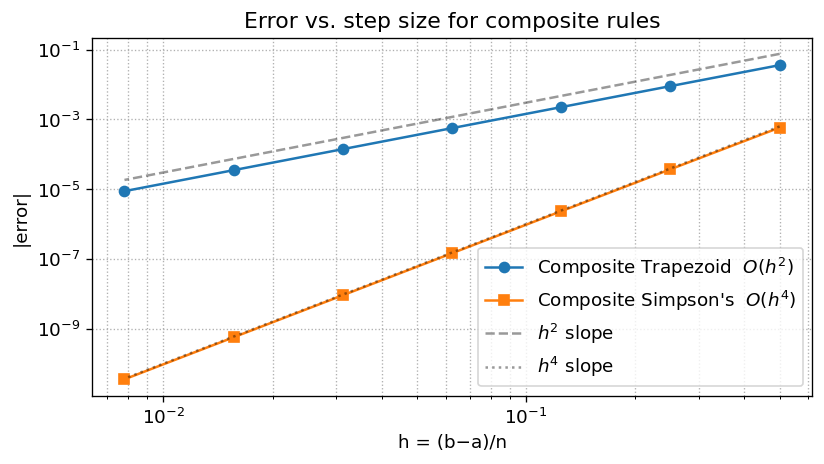

    n         h    Trap error   ratio    Simp error   ratio
--------------------------------------------------------------
    2   0.50000     3.565e-02     nan     5.793e-04     nan
    4   0.25000     8.940e-03     4.0     3.701e-05    15.7
    8   0.12500     2.237e-03     4.0     2.326e-06    15.9
   16   0.06250     5.593e-04     4.0     1.456e-07    16.0
   32   0.03125     1.398e-04     4.0     9.103e-09    16.0
   64   0.01562     3.496e-05     4.0     5.690e-10    16.0
  128   0.00781     8.740e-06     4.0     3.556e-11    16.0


In [16]:
# Convergence study: int_0^1 e^x dx = e - 1
f = np.exp
a, b = 0.0, 1.0
exact = np.e - 1

ns = [2, 4, 8, 16, 32, 64, 128]
hs = [(b - a) / n for n in ns]
trap_errors   = [abs(composite_trapezoid(f, a, b, n) - exact) for n in ns]
simp_errors   = [abs(composite_simpson(f, a, b, n)   - exact) for n in ns]

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(hs, trap_errors,  'o-', label='Composite Trapezoid  $O(h^2)$')
ax.loglog(hs, simp_errors,  's-', label="Composite Simpson's  $O(h^4)$")
# Reference slopes
h_ref = np.array(hs)
ax.loglog(hs, 0.3*h_ref**2,   'k--', alpha=0.4, label='$h^2$ slope')
ax.loglog(hs, 0.01*h_ref**4,  'k:',  alpha=0.4, label='$h^4$ slope')
ax.set_xlabel('h = (b−a)/n')
ax.set_ylabel('|error|')
ax.set_title('Error vs. step size for composite rules')
ax.legend()
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

print(f"{'n':>5}  {'h':>8}  {'Trap error':>12}  {'ratio':>6}  {'Simp error':>12}  {'ratio':>6}")
print('-' * 62)
for i, (n, h, te, se) in enumerate(zip(ns, hs, trap_errors, simp_errors)):
    tr = trap_errors[i-1]/te if i > 0 else float('nan')
    sr = simp_errors[i-1]/se if i > 0 else float('nan')
    print(f"{n:>5}  {h:>8.5f}  {te:>12.3e}  {tr:>6.1f}  {se:>12.3e}  {sr:>6.1f}")

---
## 3. Romberg Integration

This is the central iterative method of the chapter. It uses **Richardson Extrapolation** to systematically eliminate error terms.

### 3.1 Richardson Extrapolation — The Idea

Suppose an approximation $N(h)$ has the expansion:

$$Q = N(h) + K_2 h^2 + K_4 h^4 + K_6 h^6 + \cdots$$

Evaluate at $h$ and $h/2$:

$$Q = N(h)   + K_2 h^2   + K_4 h^4   + \cdots$$
$$Q = N(h/2) + K_2(h/2)^2 + K_4(h/2)^4 + \cdots$$

Multiply the second by 4 and subtract the first:

$$3Q = 4N(h/2) - N(h) - K_4\tfrac{3}{4}h^4 + \cdots$$

$$\boxed{Q \approx \frac{4N(h/2) - N(h)}{3} + O(h^4)}$$

**One extrapolation step raises the order by 2.**

### 3.2 The Romberg Table

Start with composite trapezoid approximations $R_{i,1} = T_{2^{i-1}}$ (doubling the intervals each row):

$$h_i = \frac{b-a}{2^{i-1}}, \qquad R_{i,1} = \frac{h_i}{2}\left[R_{i-1,1} + 2\sum_{\text{new nodes}} f\right]$$

Then extrapolate column by column:

$$R_{i,j} = R_{i,j-1} + \frac{R_{i,j-1} - R_{i-1,j-1}}{4^{j-1} - 1}$$

| Row $i$ | $R_{i,1}$ | $R_{i,2}$ | $R_{i,3}$ | $R_{i,4}$ |
|:---:|:---:|:---:|:---:|:---:|
| 1 | $O(h^2)$ | — | — | — |
| 2 | $O(h^2)$ | $O(h^4)$ | — | — |
| 3 | $O(h^2)$ | $O(h^4)$ | $O(h^6)$ | — |
| 4 | $O(h^2)$ | $O(h^4)$ | $O(h^6)$ | $O(h^8)$ |

**Stopping criterion:** $|R_{n,n} - R_{n-1,n-1}| < \text{TOL}$

> **Key insight:** The diagonal entries $R_{n,n}$ converge extremely fast. For smooth functions, a few rows are usually sufficient.

In [17]:
def romberg(f, a, b, n_rows=8, tol=None, verbose=True):
    """
    Returns the Romberg table R as an (n_rows x n_rows) array.
    Uses only the last two rows in memory; full table stored for display.
    Stops early if tol is given and |R[i,i] - R[i-1,i-1]| < tol.
    """
    R = np.zeros((n_rows, n_rows))
    h = b - a
    R[0, 0] = h / 2 * (f(a) + f(b))

    for i in range(1, n_rows):
        h /= 2
        # New interior points only
        new_pts = np.arange(1, 2**i, 2)
        R[i, 0] = R[i-1, 0] / 2 + h * np.sum(f(a + new_pts * h))

        # Richardson extrapolation across the row
        for j in range(1, i + 1):
            R[i, j] = R[i, j-1] + (R[i, j-1] - R[i-1, j-1]) / (4**j - 1)

        if verbose:
            row_str = "  ".join(f"{R[i,j]:.10f}" for j in range(i + 1))
            print(f"R[{i+1}]: {row_str}")

        if tol is not None and i > 0:
            if abs(R[i, i] - R[i-1, i-1]) < tol:
                return R[:i+1, :i+1], i + 1

    return R, n_rows


# Demo: int_0^pi sin(x) dx = 2
print("Romberg table for ∫₀^π sin(x) dx   (exact = 2)")
print("R[row]: R[i,1]  R[i,2]  ...")
print("-" * 55)
R, nrows = romberg(np.sin, 0, np.pi, n_rows=6, verbose=True)
print(f"\nBest estimate R[{nrows},{nrows}] = {R[nrows-1, nrows-1]:.12f}")
print(f"Error = {abs(R[nrows-1, nrows-1] - 2):.3e}")

Romberg table for ∫₀^π sin(x) dx   (exact = 2)
R[row]: R[i,1]  R[i,2]  ...
-------------------------------------------------------
R[2]: 1.5707963268  2.0943951024
R[3]: 1.8961188979  2.0045597550  1.9985707318
R[4]: 1.9742316019  2.0002691699  1.9999831309  2.0000055500
R[5]: 1.9935703438  2.0000165910  1.9999997525  2.0000000163  1.9999999946
R[6]: 1.9983933610  2.0000010334  1.9999999962  2.0000000001  2.0000000000  2.0000000000

Best estimate R[6,6] = 2.000000000001
Error = 1.322e-12


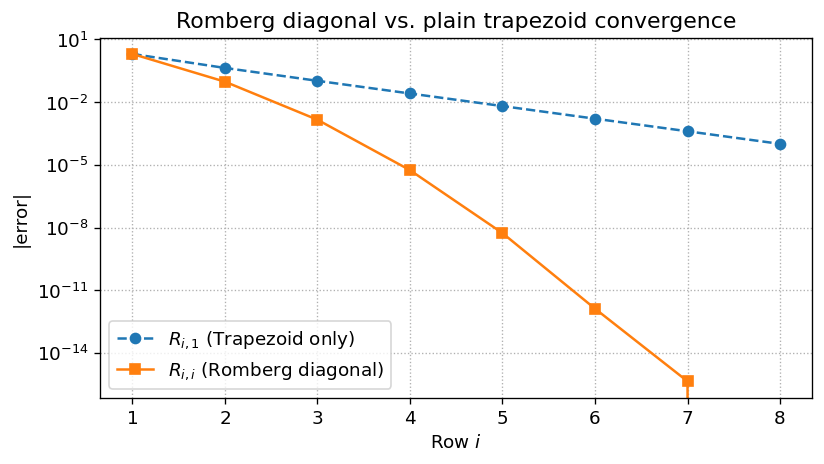

In [18]:
# Visualize convergence of diagonals vs. first column
f = np.sin
a, b, exact = 0.0, np.pi, 2.0
R, _ = romberg(f, a, b, n_rows=8, verbose=False)

rows = np.arange(1, 9)
diag_errors = [abs(R[i, i] - exact) for i in range(8)]
col1_errors = [abs(R[i, 0] - exact) for i in range(8)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(rows, col1_errors, 'o--', label='$R_{i,1}$ (Trapezoid only)')
ax.semilogy(rows, diag_errors, 's-',  label='$R_{i,i}$ (Romberg diagonal)')
ax.set_xlabel('Row $i$')
ax.set_ylabel('|error|')
ax.set_title('Romberg diagonal vs. plain trapezoid convergence')
ax.legend()
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

### 3.3 Discussion Questions

1. Why does $R_{i,1}$ require only **new** function evaluations (not recomputing old ones)?
2. For a **polynomial** of degree $d$, at which column $j$ does Romberg become exact?
3. What happens to Romberg when $f$ is **not smooth** (e.g., has a corner or a discontinuity)?

<details>
<summary>Hints</summary>

1. Trapezoid on $2^i$ intervals includes all points used on $2^{i-1}$ intervals — only the midpoints between each pair are new.
2. Column $j$ eliminates error terms up to $O(h^{2j})$. A degree-$d$ polynomial is integrated exactly when $2j > d$, so $j = \lceil (d+1)/2 \rceil$.
3. The error expansion $Q = N(h) + K_2 h^2 + K_4 h^4 + \cdots$ assumes $f \in C^\infty$. Kinks or jumps break the expansion; extrapolation can actually slow convergence or produce garbage.
</details>

---
## 4. Adaptive Quadrature

### 4.1 Motivation

Composite rules use **uniform** subintervals. But if $f$ varies slowly over most of $[a,b]$ and only spikes in a small region, we are wasting function evaluations on the flat parts.

**Adaptive quadrature** concentrates subintervals where the function is hard to integrate.

### 4.2 The Error Criterion

On $[a,b]$ with midpoint $c$, define:
- $S(a,b) = $ Simpson's rule on $[a,b]$
- $S(a,c) + S(c,b) = $ Simpson's rule on each half

From the error analysis of Simpson's rule:

$$\left|\int_a^b f - S(a,b)\right| \approx \frac{1}{15}\left|S(a,c)+S(c,b)-S(a,b)\right|$$

So we **accept** the approximation $S(a,c)+S(c,b)$ for subinterval $[a,b]$ if:

$$|S(a,c)+S(c,b)-S(a,b)| < 15\cdot\varepsilon_{\text{local}}$$

where $\varepsilon_{\text{local}} = \varepsilon_{\text{global}} \cdot \dfrac{b-a}{b_0 - a_0}$ (tolerance proportional to subinterval width).

Otherwise, **recurse** on both halves with halved tolerance.

> **The factor 15:** comes from the 4th-order error constant. Half the interval gives $h \to h/2$, so error $\to (1/2)^4 = 1/16$ of original; the two halves together have error $\approx 1/8$ of the whole, meaning the correction $S_L+S_R - S$ is $\approx 1/15$ of the true remaining error. Solving backwards: accept if correction $< 15\cdot$tol.

In [19]:
def adaptive_quadrature(f, a, b, tol=1e-6, max_depth=50):
    """
    Adaptive Simpson quadrature.
    Returns (result, n_evals).
    """
    n_evals = [0]   # mutable counter

    def simp(a, fa, m, fm, b, fb):
        return (b - a) / 6 * (fa + 4*fm + fb)

    def recurse(a, fa, m, fm, b, fb, whole, tol, depth):
        lm = (a + m) / 2;  flm = f(lm);  n_evals[0] += 1
        rm = (m + b) / 2;  frm = f(rm);  n_evals[0] += 1
        left  = simp(a, fa, lm, flm, m, fm)
        right = simp(m, fm, rm, frm, b, fb)
        delta = left + right - whole
        if depth >= max_depth:
            return left + right + delta / 15
        if abs(delta) < 15 * tol:
            return left + right + delta / 15   # one correction term for free
        return (recurse(a, fa, lm, flm, m,  fm, left,  tol/2, depth+1) +
                recurse(m, fm, rm, frm, b,  fb, right, tol/2, depth+1))

    fa, fm, fb = f(a), f((a+b)/2), f(b)
    n_evals[0] += 3
    whole = simp(a, fa, (a+b)/2, fm, b, fb)
    result = recurse(a, fa, (a+b)/2, fm, b, fb, whole, tol, 0)
    return result, n_evals[0]

In [20]:
# Compare adaptive vs. uniform Simpson on a function with a narrow peak
# f(x) = 1 / (1 + (10x - 3)^2)  on [0, 1]
# The function peaks sharply near x = 0.3

f_peak = lambda x: 1 / (1 + (10*x - 3)**2)
a, b = 0.0, 1.0
# Exact: (arctan(7) + arctan(3)) / 10
exact = (np.arctan(7) + np.arctan(3)) / 10

tol = 1e-8

# Adaptive
adapt_result, adapt_evals = adaptive_quadrature(f_peak, a, b, tol=tol)

# Uniform Simpson: find n needed to match accuracy
for n in [4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    err = abs(composite_simpson(f_peak, a, b, n) - exact)
    if err < tol:
        break
uniform_evals = n + 1

print(f"Target tolerance:      {tol:.0e}")
print(f"Exact value:           {exact:.12f}")
print()
print(f"Adaptive Simpson:")
print(f"  Result:   {adapt_result:.12f}")
print(f"  Error:    {abs(adapt_result - exact):.2e}")
print(f"  f-evals:  {adapt_evals}")
print()
print(f"Uniform Simpson (n={n}):")
print(f"  Result:   {composite_simpson(f_peak, a, b, n):.12f}")
print(f"  Error:    {abs(composite_simpson(f_peak, a, b, n) - exact):.2e}")
print(f"  f-evals:  {uniform_evals}")

Target tolerance:      1e-08
Exact value:           0.267794504459

Adaptive Simpson:
  Result:   0.267794504462
  Error:    3.06e-12
  f-evals:  285

Uniform Simpson (n=128):
  Result:   0.267794503242
  Error:    1.22e-09
  f-evals:  129


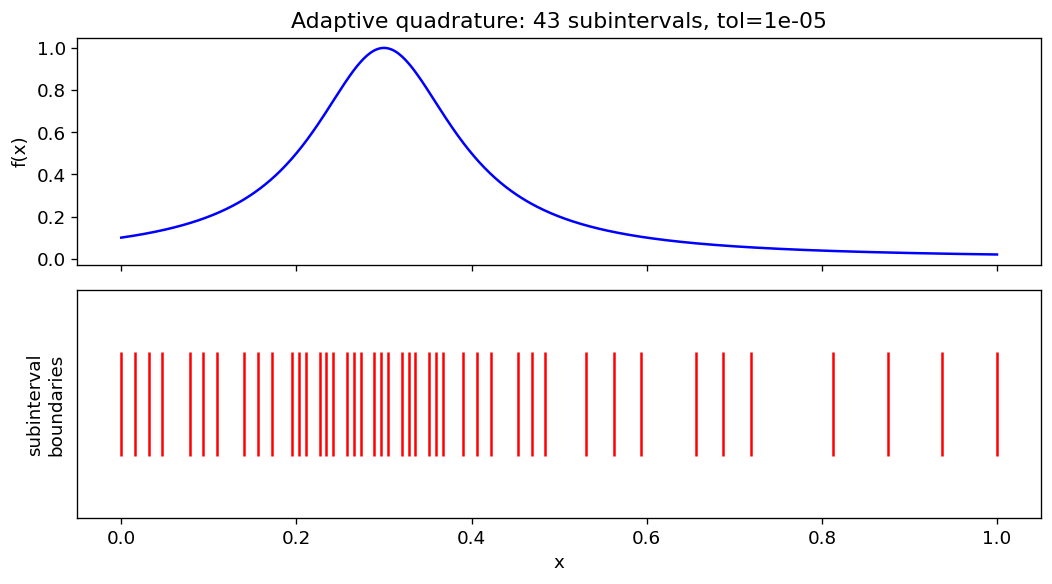

In [21]:
# Visualize WHERE the adaptive method places subintervals
# Modified version that records split points

def adaptive_with_splits(f, a, b, tol=1e-6, max_depth=50):
    splits = [a, b]

    def simp(a, fa, m, fm, b, fb):
        return (b - a) / 6 * (fa + 4*fm + fb)

    def recurse(a, fa, m, fm, b, fb, whole, tol, depth):
        lm = (a + m) / 2;  flm = f(lm)
        rm = (m + b) / 2;  frm = f(rm)
        left  = simp(a, fa, lm, flm, m, fm)
        right = simp(m, fm, rm, frm, b, fb)
        if abs(left + right - whole) < 15 * tol or depth >= max_depth:
            splits.extend([lm, m, rm])
            return left + right
        return (recurse(a, fa, lm, flm, m, fm,  left,  tol/2, depth+1) +
                recurse(m, fm, rm, frm, b, fb,  right, tol/2, depth+1))

    fa, fm, fb = f(a), f((a+b)/2), f(b)
    recurse(a, fa, (a+b)/2, fm, b, fb, simp(a, fa, (a+b)/2, fm, b, fb), tol, 0)
    return sorted(set(splits))

tol = 1e-5
split_pts = adaptive_with_splits(f_peak, 0, 1, tol=tol)
x_fine = np.linspace(0, 1, 500)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(x_fine, f_peak(x_fine), 'b-', lw=1.5)
ax1.set_ylabel('f(x)')
ax1.set_title(f'Adaptive quadrature: {len(split_pts)-1} subintervals, tol={tol:.0e}')

ax2.eventplot(split_pts, orientation='horizontal', lineoffsets=0, linelengths=0.8, colors='r')
ax2.set_xlabel('x')
ax2.set_ylabel('subinterval\nboundaries')
ax2.set_yticks([])

plt.tight_layout()
plt.show()

---
## 5. Gaussian Quadrature

Newton-Cotes rules **fix** nodes at equally-spaced points. What if we are free to choose **both** the nodes $x_i$ and the weights $w_i$?

An $n$-point rule $\displaystyle\int_{-1}^{1} f(x)\,dx \approx \sum_{i=1}^n w_i f(x_i)$ has $2n$ degrees of freedom, so we can hope to be **exact for all polynomials of degree $\le 2n-1$**.

**Gauss-Legendre:** choose $x_i$ as the roots of the $n$-th Legendre polynomial $P_n(x)$.  
Weights: $\;w_i = \dfrac{2}{(1-x_i^2)[P_n'(x_i)]^2}$

To integrate over $[a,b]$, change variables $x = \frac{b-a}{2}t + \frac{a+b}{2}$:

$$\int_a^b f(x)\,dx = \frac{b-a}{2}\int_{-1}^{1} f\!\left(\frac{b-a}{2}t+\frac{a+b}{2}\right)dt \approx \frac{b-a}{2}\sum_{i=1}^n w_i f(x_i)$$

| $n$ | Degree of exactness | Error order |
|:---:|:---:|:---:|
| 1 | 1 | $O(h^2)$ |
| 2 | 3 | $O(h^4)$ |
| 3 | 5 | $O(h^6)$ |
| $n$ | $2n-1$ | $O(h^{2n})$ |

In [23]:
def gaussian_legendre(f, a, b, n):
    nodes, weights = roots_legendre(n)          # on [-1, 1]
    t = 0.5 * (b - a) * nodes + 0.5 * (a + b)  # map to [a, b]
    return 0.5 * (b - a) * np.dot(weights, f(t))

# Accuracy vs. n for int_0^1 exp(x) dx = e - 1
f = np.exp
exact = np.e - 1
print("Gauss-Legendre on ∫₀¹ eˣ dx:")
print(f"{'n':>4}  {'approx':>18}  {'error':>12}")
print("-" * 40)
for n in range(1, 9):
    approx = gaussian_legendre(f, 0, 1, n)
    print(f"{n:>4}  {approx:>18.14f}  {abs(approx-exact):>12.3e}")

Gauss-Legendre on ∫₀¹ eˣ dx:
   n              approx         error
----------------------------------------
   1    1.64872127070013     6.956e-02
   2    1.71789637800750     3.855e-04
   3    1.71828100437252     8.241e-07
   4    1.71828182752608     9.330e-10
   5    1.71828182845839     6.537e-13
   6    1.71828182845904     4.441e-16
   7    1.71828182845905     4.441e-16
   8    1.71828182845905     0.000e+00


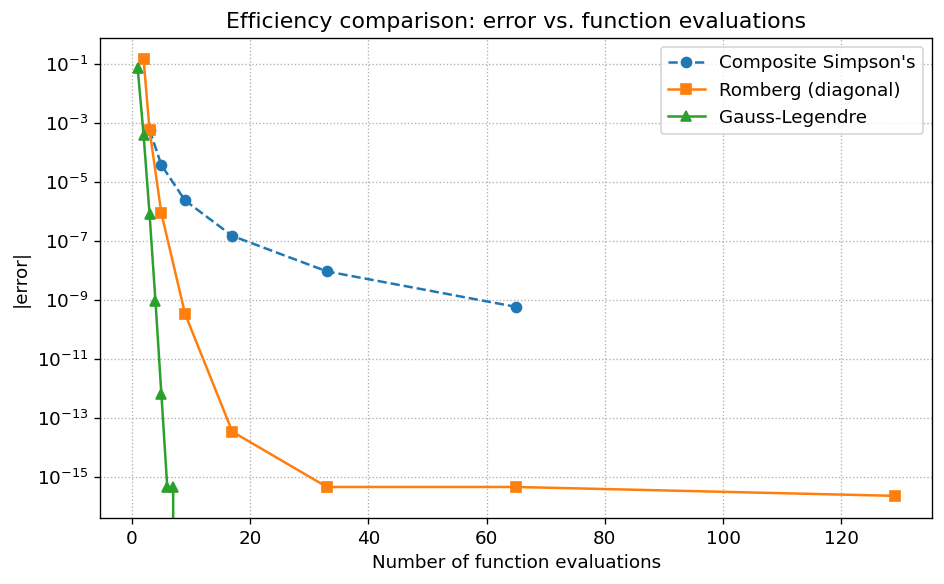

In [ ]:
# Head-to-head: error vs. number of function evaluations
f = np.exp
a, b, exact = 0.0, 1.0, np.e - 1

# Composite Simpson (n subintervals → n+1 evaluations)
ns_simp = [2, 4, 8, 16, 32, 64]
simp_ev  = [n + 1 for n in ns_simp]
simp_err = [abs(composite_simpson(f, a, b, n) - exact) for n in ns_simp]

# Romberg (row i → 2^(i-1)+1 unique evaluations total)
R_full, _ = romberg(f, a, b, n_rows=8, verbose=False)
rom_ev  = [2**i + 1 for i in range(8)]
rom_err = [abs(R_full[i, i] - exact) for i in range(8)]

# Gauss-Legendre (n points per evaluation)
gl_ev  = list(range(1, 9))
gl_err = [abs(gaussian_legendre(f, a, b, n) - exact) for n in gl_ev]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(simp_ev, simp_err, 'o--', label="Composite Simpson's")
ax.semilogy(rom_ev,  rom_err,  's-',  label='Romberg (diagonal)')
ax.semilogy(gl_ev,   gl_err,   '^-',  label='Gauss-Legendre')
ax.set_xlabel('Number of function evaluations')
ax.set_ylabel('|error|')
ax.set_title('Efficiency comparison: error vs. function evaluations')
ax.legend()
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

---
## 6. Error Estimation — Summary

| Method | Error term | Order | Notes |
|:---|:---:|:---:|:---|
| Composite Trapezoid | $-\frac{b-a}{12}h^2 f''(\xi)$ | $O(h^2)$ | Requires $f \in C^2$ |
| Composite Simpson | $-\frac{b-a}{180}h^4 f^{(4)}(\xi)$ | $O(h^4)$ | Requires $f \in C^4$ |
| Romberg $R_{n,n}$ | $O(h^{2n})$ | Very high | Requires $f \in C^{2n}$ |
| Adaptive (Simpson) | $\approx \frac{1}{15}\|S_L+S_R-S\|$ | — | Error **estimated** from the computation itself |
| Gauss-Legendre $n$ pts | $O(h^{2n})$ | Exponential | Optimal for smooth $f$ on fixed interval |

### When to use what

- **Smooth $f$, known interval**: Gauss-Legendre or Romberg — fewer evaluations for high accuracy.
- **$f$ has localized features** (spike, steep gradient): Adaptive quadrature.
- **Simple / general purpose**: Composite Simpson.
- **$f$ is rough or non-smooth**: Low-order rules with fine uniform mesh, or specialized methods.

---
## Exercises

### Exercise 1 — Error bound
For $\displaystyle I = \int_0^2 x^2 e^x\,dx$, find the minimum $n$ such that the Composite Trapezoid error is less than $10^{-4}$.  
Use the error formula $|E_n| \le \dfrac{(b-a)^3}{12n^2}\max_{x\in[a,b]}|f''(x)|$.

Then verify numerically.

### Exercise 2 — Romberg table by hand
Compute the first $3\times3$ Romberg table for $\displaystyle\int_0^1 x^3\,dx = 0.25$ by hand, then verify with the `romberg` function. At which entry does the table become exact, and why?

### Exercise 3 — Adaptive quadrature
Apply `adaptive_quadrature` to $f(x) = \sqrt{x}\,\sin(1/x)$ on $[0.01,\, 1]$ with tolerance $10^{-6}$.  
How many function evaluations are used? Compare to uniform Composite Simpson at the same accuracy.

### Exercise 4 — Gaussian quadrature degree of exactness
Verify that 3-point Gauss-Legendre is exact for $p(x) = x^5$ on $[-1,1]$ but not for $x^6$.  
What is the theoretical explanation?

### Exercise 5 — Non-smooth function
Apply all four methods to $\displaystyle\int_0^1 |x - 0.5|\,dx = 0.25$.  
Plot error vs. number of evaluations. Which method suffers the most, and why?

In [ ]:
# Exercise 1 workspace
# Hint: f(x) = x^2 e^x, so f''(x) = (x^2 + 4x + 2) e^x
# max on [0,2] is at x = 2

def f_ex1(x): return x**2 * np.exp(x)
exact_ex1 = 2*np.exp(2) - 2   # integrate by parts

# Your code here


In [ ]:
# Exercise 2 workspace
def f_ex2(x): return x**3

# Your code here


In [ ]:
# Exercise 3 workspace
def f_ex3(x): return np.sqrt(x) * np.sin(1/x)

# Your code here


In [ ]:
# Exercise 4 workspace
# Your code here


In [ ]:
# Exercise 5 workspace
def f_ex5(x): return np.abs(x - 0.5)

# Your code here
